# 🚀 SAIR PyTorch Mastery - Lecture 6: Many-to-Many Architecture
## From Classification to Generation: Teaching Machines to Write

**Course:** Applied Deep Learning with PyTorch  
**Module:** Sequence & NLP  
**Instructor:** Mohammed Awad Ahmed (Silva)  
**SAIR Community:** Building Sudan's AI Future 🇸🇩

---

## 📘 Welcome to Text Generation!

Today we build on everything you mastered in Lecture 5. You learned how to **understand** sequences (sentiment analysis). Now you'll learn how to **create** sequences - teaching machines to write like humans!

### Where You Are in Your Journey

```
Module 1: PyTorch Fundamentals → Tensors, autograd, training loops
Module 2: Vision & CNNs → Spatial reasoning with images
Module 3: Sequence & NLP 
    ├── Lecture 6: Many-to-One (Classification) ✓
    ├── Lecture 7: Many-to-Many (Generation) ← YOU ARE HERE
    ├── Lecture 8A: HuggingFace Ecosystem 
    └── Lecture 8B: Fine-tuning (Make It Yours)
```

![mapping](../../../src/visuals/rnn_input_output_setups.png)

*[credit](https://wandb.ai/ayush-thakur/dl-question-bank/reports/LSTM-RNN-in-Keras-Examples-of-One-to-Many-Many-to-One-Many-to-Many---VmlldzoyMDIzOTM)*

In our Sequence Classification (Lecture 5), we had a **Many-to-One** model: sequence of inputs → single output. Today we build a **Many-to-Many** model: sequence in → sequence out. Specifically, we'll build an AI that can generate Harry Potter!

A lot of this lesson was inspired by [Andrej Karpathy's work](https://github.com/karpathy/ng-video-lecture/blob/master/bigram.py) on character-level language models.

### What You'll Master Today

**Architecture Understanding:**
- ✅ Many-to-Many vs Many-to-One architectures
- ✅ Two ways to feed data into an LSTM
- ✅ Next-token prediction task
- ✅ Teacher Forcing vs Free Running (NEW!)
- ✅ Autoregressive generation fundamentals (NEW!)

**Generation Techniques:**
- ✅ Greedy decoding (always pick most likely)
- ✅ Multinomial sampling (random sampling from probabilities)
- ✅ Temperature sampling (control randomness)
- ✅ Top-k sampling (limit to top candidates)
- ✅ Beam Search (NEW! Production standard)
- ✅ Repetition Penalty (NEW! Prevents loops)
- ✅ Perplexity (NEW! Evaluation metric)

**Practical Implementation:**
- ✅ Build a character-level Harry Potter generator
- ✅ Train an LSTM for next-character prediction
- ✅ Compare sampling strategies
- ✅ Generate text interactively
- ✅ Debug generation with visualization tools (NEW!)

**Modern Transformers:**
- ✅ Understand the Hugging Face ecosystem
- ✅ Map LSTM concepts to transformer equivalents
- ✅ Master generation parameters (temperature, top-k, top-p, beam search)
- ✅ See how your knowledge applies to GPT, Llama, and modern LLMs
- ✅ Bridge to GPT-2 from scratch project (NEW!)

---

## ⚙️ Initial Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


---

# 🎯 PART 1: Two Ways to Feed Data into an LSTM

Before diving into generation, we need to understand the two ways we can pass data into an LSTM:

1. **Pass entire sequence at once** (efficient for training)
2. **Pass one token at a time** (necessary for generation)

Let's verify they're equivalent!

In [2]:
batch_size = 5        # How Many Samples
sequence_length = 15   # Sequence Length Per Sample
input_size = 10       # Dimension of vector for each timestep
hidden_size = 20      # LSTM hidden dimension
num_layers = 2        # Number of LSTM layers

lstm = nn.LSTM(input_size=input_size, 
               hidden_size=hidden_size, 
               num_layers=num_layers, 
               batch_first=True)

rand = torch.randn(batch_size, sequence_length, input_size)

### METHOD 1: Process entire sequence at once ###
h0 = torch.zeros(num_layers, batch_size, hidden_size)
c0 = torch.zeros(num_layers, batch_size, hidden_size)
method_1_outs, (hn, cn) = lstm(rand, (h0, c0))

### METHOD 2: Process step by step ###
h = torch.zeros(num_layers, batch_size, hidden_size)
c = torch.zeros(num_layers, batch_size, hidden_size)
outs = []

for i in range(sequence_length):
    token = rand[:, i, :].unsqueeze(1)  # Take one token, keep sequence dim
    out, (h, c) = lstm(token, (h, c))
    outs.append(out)

method_2_outs = torch.cat(outs, dim=1)

print(f"Methods produce same output? {torch.allclose(method_1_outs, method_2_outs)}")

Methods produce same output? True


### 🛑 STOP & THINK
**Why do we need both methods?**
- Method 1: Efficient for training (parallel computation on GPU)
- Method 2: Essential for generation (we don't have future tokens during inference!)

---

# 🎯 PART 2: The Next Token Prediction Task

## How Language Models Learn

Training a language model is surprisingly simple: **predict the next character!**

```
Dataset: "Strange how nearsighted being invisible can make you"

Step 1: Tokenize (character level)
['S','t','r','a','n','g','e',' ','h','o','w',' ','n','e','a','r','s','i','g','h','t','e','d','...']

Step 2: Create input-target pairs
Input:  ['S','t','r','a','n','g','e',' ','h','o','w',' ','n','e','a','r','s','i','g','h','t','e','d']
Target: ['t','r','a','n','g','e',' ','h','o','w',' ','n','e','a','r','s','i','g','h','t','e','d',' ']

The target is just the input shifted RIGHT by one position!
```

## 🧠 Mental Model: The Autocomplete

```
Think of your phone's keyboard:

You type:     "H" 
Phone predicts: "e", "i", "a", "o"

You type:     "He"
Phone predicts: "l", "r", " ", "y"

You type:     "Hel"
Phone predicts: "l", "p", "o", "i"

Each prediction uses ALL previous characters as context!
```

## 🔄 Autoregressive Generation Explained

```python
"""
AUTOREGRESSIVE GENERATION (what we're doing):
    Step 1: P(x₁) = model( [START] )
    Step 2: P(x₂|x₁) = model( [START, x₁] )
    Step 3: P(x₃|x₁,x₂) = model( [START, x₁, x₂] )
    
    Each prediction depends on ALL previous predictions!
    This is why generation is sequential and can't be parallelized.

NON-AUTOREGRESSIVE (advanced, for translation):
    P(x₁,x₂,x₃|source) in one shot
    Faster but lower quality
"""
```

---

# 🎯 PART 3: Building a Character-Level Text Generator

## Step 1: Load Harry Potter Books

In [3]:
# Update this path to where your Harry Potter texts are stored
path_to_data = "/home/silva/SILVA.AI/Projects/SAIR/4_Applied Deep Learning with PyTorch/3_Sequence and NLP/harry_potter_txt"# If the folder doesn't exist or is empty or has no .txt files, use sample


def _load_texts_from_folder(folder):
    if not os.path.isdir(folder):
        print(f"⚠️ Path not found or not a directory: {folder}")
        return None

    files = sorted([
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f)) and f.lower().endswith(".txt")
    ])
    if not files:
        print(f"⚠️ No .txt files found in: {folder}")
        return None

    texts = []
    for fname in files:
        p = os.path.join(folder, fname)
        try:
            with open(p, "r", encoding="utf-8", errors="ignore") as f:
                raw = f.read()
        except Exception as e:
            print(f"⚠️ Failed to read {p}: {e}")
            continue

        # Remove lines that contain "Page" and normalize whitespace
        lines = [line for line in raw.splitlines() if "Page" not in line]
        cleaned = " ".join(" ".join(lines).split())
        if cleaned:
            texts.append(cleaned)

    return " ".join(texts) if texts else None

all_text = _load_texts_from_folder(path_to_data)
if all_text is None:
    print("⚠️ Harry Potter texts not usable. Using sample text for demonstration.")
    all_text = "Harry Potter was a wizard. He went to Hogwarts School of Witchcraft and Wizardry. " * 100
else:
    print(f"✅ Loaded text from: {path_to_data}")

print(f"Total characters: {len(all_text):,}")
print(f"First 200 chars:\n{all_text[:200]}")

✅ Loaded text from: /home/silva/SILVA.AI/Projects/SAIR/4_Applied Deep Learning with PyTorch/3_Sequence and NLP/harry_potter_txt
Total characters: 6,273,611
First 200 chars:
/ THE BOY WHO LIVED Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much. They were the last people you’d expect to be involved in


## Step 2: Build Character Vocabulary

In [4]:
# Find all unique characters
unique_chars = sorted(list(set(all_text)))
vocab_size = len(unique_chars)

print(f"Unique characters: {vocab_size}")
print(f"Characters: {''.join(unique_chars[:50])}...")

# Create mappings
char2idx = {c:i for i, c in enumerate(unique_chars)}
idx2char = {i:c for i, c in enumerate(unique_chars)}

# Test
test_char = "H"
print(f"\n'{test_char}' → {char2idx[test_char]} → '{idx2char[char2idx[test_char]]}'")

Unique characters: 91
Characters:  !"%&'()*,-./0123456789:;>?ABCDEFGHIJKLMNOPQRSTUVW...

'H' → 34 → 'H'


## Step 3: Create Data Generator

Instead of a full Dataset class (like in Lecture 5), we'll sample random chunks from the text. This is simpler and works well for language modeling!

In [5]:
class DataGenerator:
    """Samples random sequences from text for next-character prediction"""
    def __init__(self, text, seq_len=100):
        self.text = text
        self.seq_len = seq_len
        self.total_chars = len(text)

    def get_batch(self, batch_size):
        """Return a batch of (input, target) sequences"""
        inputs = []
        targets = []

        for _ in range(batch_size):
            # Pick random starting point
            start = np.random.randint(0, self.total_chars - self.seq_len - 1)
            end = start + self.seq_len
            
            # Input: sequence, Target: shifted by one
            input_seq = self.text[start:end]
            target_seq = self.text[start+1:end+1]
            
            # Convert to indices
            inputs.append([char2idx[c] for c in input_seq])
            targets.append([char2idx[c] for c in target_seq])

        return torch.tensor(inputs), torch.tensor(targets)

# Test it
data_gen = DataGenerator(all_text, seq_len=20)
x, y = data_gen.get_batch(2)
print(f"Input shape: {x.shape}")
print(f"Target shape: {y.shape}")

# Decode first sample
print(f"\nInput:  {''.join([idx2char[i.item()] for i in x[0]])}")
print(f"Target: {''.join([idx2char[i.item()] for i in y[0]])}")

Input shape: torch.Size([2, 20])
Target shape: torch.Size([2, 20])

Input:  ably lighter, they w
Target: bly lighter, they we


### 🛑 STOP & THINK
Notice how target is input shifted right:
```
Input:  "Harry Potter was a "
Target: "arry Potter was a w"
```
The model must learn to predict 'a' from 'H', 'r' from 'a', etc.!

---

# 🎯 PART 4: Building the LSTM Generator

This looks similar to our Sequence Classification model from Lecture 5, with key changes:
- Final layer predicts vocabulary size (not binary classes)
- We add a `generate` method for text generation
- We introduce **sampling** instead of always taking the most likely character

In [ ]:
# ## Single generate() with temperature control

# %%
import torch
import torch.nn as nn
import numpy as np

class LSTMGenerator(nn.Module):
    """LSTM for character-level text generation"""
    def __init__(self, vocab_size, embedding_dim=128, hidden_size=256, num_layers=3):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Core components
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        
        print(f"Model built | Vocab: {vocab_size} | Params: {sum(p.numel() for p in self.parameters()):,}")

    def forward(self, x, states=None):
        # x shape: (batch, seq_len)
        x = self.embedding(x)  # (batch, seq_len, embedding_dim)
        
        if states is None:
            h = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
            c = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
            states = (h, c)
            
        output, states = self.lstm(x, states)
        logits = self.fc(output)  # (batch, seq_len, vocab_size)
        return logits, states

    def generate(self, prompt, max_new_tokens=100, temperature=1.0):
        """
        Generate text from a prompt
        temperature = 0: greedy (always pick most likely)
        temperature > 0: sampling with controlled randomness
        """
        self.eval()
        
        # Convert prompt to indices
        indices = [char2idx.get(c, 0) for c in prompt]
        input_ids = torch.tensor(indices).unsqueeze(0)
        
        # Initialize states
        h = torch.zeros(self.num_layers, 1, self.hidden_size)
        c = torch.zeros(self.num_layers, 1, self.hidden_size)
        states = (h, c)
        
        all_indices = indices.copy()
        
        for _ in range(max_new_tokens):
            with torch.no_grad():
                logits, states = self(input_ids, states)
            
            # Get last token logits
            last_token_logits = logits[0, -1, :]
            
            if temperature == 0:  # Greedy
                next_idx = torch.argmax(last_token_logits).item()
            else:  # Temperature sampling
                scaled_logits = last_token_logits / temperature
                probs = torch.softmax(scaled_logits, dim=-1)
                next_idx = torch.multinomial(probs, 1).item()
            
            all_indices.append(next_idx)
            input_ids = torch.tensor([[next_idx]])
        
        return ''.join([idx2char[i] for i in all_indices])


```markdown
## Understanding Greedy Decoding vs Temperature Sampling

Our `generate()` function uses the `temperature` parameter to switch between two fundamentally different strategies for choosing the next character:

---

### 🟢 Greedy Decoding (`temperature=0`)

```python
next_idx = torch.argmax(last_token_logits).item()
```

**What it does:** Always picks the character with the highest probability.

**Analogy:** Like always ordering your favorite dish at a restaurant, never trying anything new.

**Characteristics:**
- ✅ Deterministic - same input always produces same output
- ✅ Safe and predictable
- ❌ Can get stuck in repetitive loops
- ❌ Lacks creativity and diversity

**Best for:** Factual answers, code generation, translation

---

### 🔴 Temperature Sampling (`temperature>0`)

```python
scaled_logits = last_token_logits / temperature
probs = torch.softmax(scaled_logits, dim=-1)
next_idx = torch.multinomial(probs, 1).item()
```

**What it does:** Rolls a weighted die where each character's chance of being picked equals its probability.

**Analogy:** Like spinning a roulette wheel where bigger slices have higher chance, but anything could win.

**Characteristics:**
- ✅ Stochastic - same input can produce different outputs
- ✅ Creative and diverse
- ✅ More natural-sounding text
- ❌ Can occasionally pick nonsensical options

**Best for:** Stories, dialogue, poetry, brainstorming

---

### 🌡️ How Temperature Shapes the Distribution

The temperature parameter doesn't change which characters are most likely—it changes HOW likely the top choice is compared to others.

```
Original probabilities: [0.7, 0.2, 0.1]

Temperature = 0.5 (sharper):  [0.85, 0.12, 0.03]  ← More conservative
Temperature = 1.0 (original):  [0.7, 0.2, 0.1]    ← Balanced
Temperature = 2.0 (flatter):   [0.5, 0.3, 0.2]    ← More random
```

**Low temperature (<1.0):** Magnifies probability differences → more predictable
**High temperature (>1.0):** Evens out probabilities → more creative/chaotic

---

### 🎯 The Mental Model

| Strategy | Decision Method | Temperature | Analogy |
|----------|-----------------|-------------|---------|
| **Greedy** | Always tallest bar | `= 0` | Always order "The usual" |
| **Sampling** | Roll weighted die | `> 0` | Let fate decide the menu |

---

### 🚀 Beyond Basic Sampling (GPT Module Preview)

These two strategies are the foundation. In our transformer/GPT module, we'll build on them with:

| Technique | What It Adds |
|-----------|--------------|
| **Top-k Sampling** | Only roll the die among the top k candidates (prevents rare, weird choices) |
| **Top-p (Nucleus)** | Dynamically decide how many candidates to keep based on confidence |
| **Beam Search** | Keep multiple sequences alive and choose the best overall path |
| **Repetition Penalty** | Reduce probability of tokens that already appeared |

**But for now:** Master the difference between greedy (always pick best) and sampling (roll weighted die). Everything else is just refinement!
```

---

# 🎯 PART 5: Training the Generator

## Understanding Cross-Entropy for Generation

Our model returns shape **[batch x seq_len x vocab_size]** and labels are **[batch x seq_len]**. 
PyTorch's CrossEntropyLoss expects:
- Input: (N, C, d1, d2, ...) where C is the class dimension
- Target: (N, d1, d2, ...)

So we need to transpose to **[batch x vocab_size x seq_len]**!

Model built | Vocab: 91 | Params: 1,482,971

TRAINING TEXT GENERATOR
Iteration 0, Loss: 4.5251
Sample: Spells BD'NwtANtdNJ|d&7;8b8’-rJOTd/|”hyA4kf?M;uT(rR-UU4|o...

Iteration 500, Loss: 2.1411
Sample: Spells first of that he saure with the Sunder got had not...

Iteration 1000, Loss: 1.4416
Sample: Spells snake. “The Ministry lights in the chilly on the w...

Iteration 1500, Loss: 1.3054
Sample: Spells of the Death Eaters was room by that,” said The re...

Iteration 2000, Loss: 1.2423
Sample: Spells and it had already, he has just been hard it, real...

Iteration 2500, Loss: 1.2035
Sample: Spells and pulled at the door when she was flickered into...



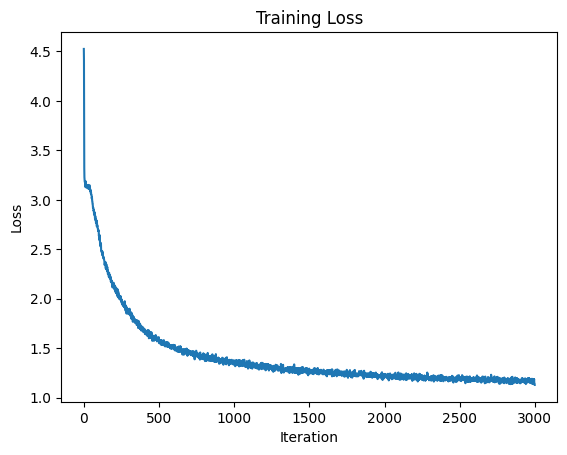

In [7]:
def train_model(model, data_gen, iterations=3000, batch_size=128, lr=0.003):
    """Train the text generator - simplified version"""
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    
    losses = []
    
    print("\n" + "="*50)
    print("TRAINING TEXT GENERATOR")
    print("="*50)
    
    for iteration in range(iterations):
        # Get batch
        x, y = data_gen.get_batch(batch_size)
        
        # Forward pass
        logits, _ = model(x)
        logits = logits.transpose(1, 2)  # Reshape for loss function
        loss = loss_fn(logits, y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
        # Print progress
        if iteration % 500 == 0:
            avg_loss = np.mean(losses[-500:])
            print(f"Iteration {iteration}, Loss: {avg_loss:.4f}")
            
            # Quick generation sample
            model.eval()
            sample = model.generate("Spells ", max_new_tokens=50, temperature=0.8)
            print(f"Sample: {sample[:100]}...\n")
            model.train()
    
    return losses

# Train
model = LSTMGenerator(vocab_size)
data_gen = DataGenerator(all_text, seq_len=128)
losses = train_model(model, data_gen, iterations=3000)

# Plot loss
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

### 🛑 STOP & THINK
**Why do we transpose the output for loss calculation?**
- CrossEntropy expects class dimension as the second dimension
- Our output is (batch, seq_len, vocab) → we need (batch, vocab, seq_len)
- The transpose swaps the vocab and seq_len dimensions!

**What is Perplexity?**
- Perplexity = exp(cross_entropy_loss)
- Lower is better!
- Perplexity = 50 means model is as confused as choosing between 50 options

---

## Sampling Strategy Summary

| Strategy | Description | When to Use |
|----------|-------------|-------------|
| **Greedy** | Always pick highest probability | When you want safe, predictable text |
| **Temperature** | Controls randomness: low = conservative, high = creative | Fine-tune creativity |
| **Top-k** | Only consider k most likely tokens | Prevent rare, weird choices |
| **Top-p (nucleus)** | Keep tokens with cumulative prob > p | Adaptive filtering  |
| **Beam Search** | Keep multiple hypotheses | Higher quality, slower  |
| **Repetition Penalty** | Reduce probability of repeated tokens | Prevent loops  |

---

# 🎯 PART 7: Interactive Generation

Let's compare all sampling strategies side-by-side!

In [17]:
# %% [markdown]
# # 🎯 Testing the Trained Model

# %%
# After training is complete, let's test the model

print("\n" + "="*60)
print("🤖 TESTING THE TRAINED GENERATOR")
print("="*60)

# Test prompts
test_prompts = [
    "Harry ",
    "Ron ",
    "Hermione ",
    "Hogwarts ",
    "The magic ",
    "Voldemort ",
    "Dumbledore "
]

# Test different temperatures
temperatures = [0, 0.5, 0.8, 1.2]

for prompt in test_prompts:
    print(f"\n📝 PROMPT: '{prompt}'")
    print("-" * 50)
    
    for temp in temperatures:
        if temp == 0:
            output = model.generate(prompt, max_new_tokens=100, temperature=0)
            print(f"\n🔹 GREEDY (temp=0):")
        else:
            output = model.generate(prompt, max_new_tokens=100, temperature=temp)
            print(f"\n🔹 TEMP={temp}:")
        print(f"   {output}")




🤖 TESTING THE TRAINED GENERATOR

📝 PROMPT: 'Harry '
--------------------------------------------------



🔹 GREEDY (temp=0):
   Harry and Hermione said, “I don’t know what you were the one of the Ministry of Magic was the one who was 

🔹 TEMP=0.5:
   Harry heard his eyes within the sight of the door and the Goblet of Fire - J.K. Rowling Harry was a few mi

🔹 TEMP=0.8:
   Harry saw that Ron said, a statue, retreating. “Pives ... now, were it?” said Ron. “Yeah, I’m not, come on

🔹 TEMP=1.2:
   Harry or his left Minager and Goy pay this silverheealing beast. “Ihich moment! Lord, and trynner,” said G

📝 PROMPT: 'Ron '
--------------------------------------------------

🔹 GREEDY (temp=0):
   Ron and Hermione said, “I don’t know what you were the one of the Ministry of Magic was the one who was 

🔹 TEMP=0.5:
   Ron and Ron was staring at him. “I don’t know where the corridor has come back to a bad!” said Harry. “S

🔹 TEMP=0.8:
   Ron did not say, bringing at the fire. She had a few possession Professor Pettigrew with his mind and th

🔹 TEMP=1.2:
   Ron loved and them, siquading rang: He spotted

---

# 🎯 PART 8: Sudanese Applications

## Sudanese Poetry Generator

```python
"""
Train on Sudanese poetry to generate new verses

Example training data:
"يا بلاد الذهب والنيل العظيم"
"في حب السودان نبض القلب ينادي"
"يا أم درمان يا حبة القلب"
"الخرطوم تلتقي فيها الأنهار"
"""

# The same code works with Arabic text!
arabic_text = "يا بلاد الذهب والنيل العظيم في حب السودان نبض القلب ينادي"
arabic_chars = sorted(list(set(arabic_text)))
print(f"Arabic characters: {''.join(arabic_chars)}")
```

## 🆕 NEW: Arabic Script Challenges

```python
"""
ARABIC-SPECIFIC CHALLENGES FOR GENERATION:

1. Right-to-Left text: Generation order matters!
2. Contextual letter forms: 
   "ع" looks different at start (عـ), middle (ـعـ), end (ـع)
3. Diacritics: تَعلُّم vs تعلم (meaning changes!)
4. Dialectal variations: ما عندو لازمة (Sudanese) vs ليس له فائدة (MSA)

Our character-level approach handles this naturally:
    Input:  ["ي", "ا", " ", "ب", "ل", "ا", "د"]
    Target: ["ا", " ", "ب", "ل", "ا", "د", " "]
"""
```

## Sudanese Dialect Generator

```python
"""
You could train on Sudanese dialect text to generate:
- Proverbs and sayings
- Conversational responses
- Poetry in local dialect

Example: "الناس في السودان طيبين كتير"
"""
```

---

# 🤖 PART 9: Transformers Deep Dive - The Modern Way

You've just built a text generator from scratch using LSTMs. Now let's see how the pros do it with Transformers!

In [ ]:
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM

print("="*60)
print("🤯 THE HUGGING FACE ECOSYSTEM")
print("="*60)

# === 9.1 The Pipeline: One Line of Code ===
print("\n📦 9.1 The Pipeline - What took us 300 lines of code:")
generator = pipeline('text-generation', model='gpt2')
output = generator("Harry Potter walked into Hogwarts", 
                  max_length=50, 
                  num_return_sequences=1)[0]['generated_text']
print(f"   Output: {output}")

# === 9.2 Under the Hood: Tokenizer ===
print("\n🔤 9.2 The Tokenizer - Our char2idx on steroids:")
tokenizer = AutoTokenizer.from_pretrained('gpt2')
print(f"   Vocabulary size: {tokenizer.vocab_size:,}")
print(f"   Special tokens: {tokenizer.special_tokens_map}")
text = "Harry Potter"
tokens = tokenizer.encode(text)
print(f"   '{text}' → {tokens} → '{tokenizer.decode(tokens)}'")

# Show subword tokenization
example = "unbelievable"
tokens = tokenizer.encode(example)
subwords = [tokenizer.decode([t]) for t in tokens]
print(f"   Subword magic: '{example}' → {subwords}")

🤯 THE HUGGING FACE ECOSYSTEM

📦 9.1 The Pipeline - What took us 300 lines of code:


Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   Output: Harry Potter walked into Hogwarts for the first time in more than a year. He had been a student of Muggle literature for ten years when he arrived at Hogwarts, and had been a master of English since he had grown up.

Now he was learning to read and write, and had become an expert at the Harry Potter books. He had come to learn that the magic was at work, and that there were many possibilities for it. He was even more amazed by Harry. He had come to know that he was Harry Potter's friend, and that he was a wizard, and that he was the only one in the wizarding world who could stop Voldemort.

But then, he noticed that the other wizards were also Harry Potter's friends. So he decided to show them the way, even though he knew they were not Harry Potter's friends.

He began to read the books. He was not going to tell them about all the things Harry Potter knew about, but to go find out about them. He was sure that if he told them everything, someone would be very interested in hi

🤯 THE HUGGING FACE ECOSYSTEM

📦 9.1 The Pipeline - What took us 300 lines of code:


Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


KeyboardInterrupt: 

## 9.3 Tokenization Deep Dive: Character vs Word vs Subword

Let's compare our character-level approach with modern tokenization:

In [10]:
def compare_tokenizers(text="Harry Potter and the Sorcerer's Stone"):
    """Compare different tokenization approaches"""
    
    # Our character-level approach
    char_tokens = list(text)
    
    # Word-level (simple split)
    word_tokens = text.split()
    
    # GPT-2 subword tokenizer
    gpt2_tokenizer = AutoTokenizer.from_pretrained('gpt2')
    subword_ids = gpt2_tokenizer.encode(text)
    subword_tokens = [gpt2_tokenizer.decode([id]) for id in subword_ids]
    
    print("="*70)
    print(f"TOKENIZATION COMPARISON for: '{text}'")
    print("="*70)
    
    print(f"\n📝 Character-level (our LSTM): {len(char_tokens)} tokens")
    print(f"   {char_tokens[:20]}...")
    print(f"   ✅ Handles any word   ❌ Very long sequences")
    print(f"   ❌ No word meaning    ✅ No OOV problem")
    
    print(f"\n📚 Word-level (simple): {len(word_tokens)} tokens")
    print(f"   {word_tokens}")
    print(f"   ✅ Word meanings      ❌ OOV problems")
    print(f"   ✅ Shorter sequences  ❌ Large vocabulary")
    
    print(f"\n🚀 Subword-level (GPT-2): {len(subword_tokens)} tokens")
    print(f"   {subword_tokens}")
    print(f"   ✅ Best of both!      ⚠️ Slightly complex")
    print(f"   ✅ Handles any word   ✅ Reasonable vocab size")
    print(f"   ✅ Preserves meaning  ✅ No OOV problems")

compare_tokenizers()

TOKENIZATION COMPARISON for: 'Harry Potter and the Sorcerer's Stone'

📝 Character-level (our LSTM): 37 tokens
   ['H', 'a', 'r', 'r', 'y', ' ', 'P', 'o', 't', 't', 'e', 'r', ' ', 'a', 'n', 'd', ' ', 't', 'h', 'e']...
   ✅ Handles any word   ❌ Very long sequences
   ❌ No word meaning    ✅ No OOV problem

📚 Word-level (simple): 6 tokens
   ['Harry', 'Potter', 'and', 'the', "Sorcerer's", 'Stone']
   ✅ Word meanings      ❌ OOV problems
   ✅ Shorter sequences  ❌ Large vocabulary

🚀 Subword-level (GPT-2): 7 tokens
   ['Harry', ' Potter', ' and', ' the', ' Sorcerer', "'s", ' Stone']
   ✅ Best of both!      ⚠️ Slightly complex
   ✅ Handles any word   ✅ Reasonable vocab size
   ✅ Preserves meaning  ✅ No OOV problems


## 9.4 The Generate Method: Parameters Explained

Remember our `generate()` method with temperature and top_k? Hugging Face has ALL those options and MORE!

In [11]:
def explore_generate_params():
    """Deep dive into Hugging Face generate parameters"""
    
    tokenizer = AutoTokenizer.from_pretrained('gpt2')
    model = AutoModelForCausalLM.from_pretrained('gpt2')
    
    prompt = "The magic wand"
    inputs = tokenizer(prompt, return_tensors='pt')
    
    print("="*70)
    print("🎛️  HUGGING FACE GENERATE PARAMETERS")
    print("="*70)
    print("""
    Our LSTM generate():
        generate(prompt, max_new_tokens, temperature, top_k)
    
    Hugging Face generate():
        generate(inputs, 
                max_length=50,           # Total sequence length
                max_new_tokens=30,        # New tokens to generate
                do_sample=True,           # Use sampling (vs greedy)
                temperature=0.8,           # Our temperature!
                top_k=50,                  # Our top_k!
                top_p=0.95,                 # Nucleus sampling (new!)
                num_beams=5,                # Beam search (new!)
                no_repeat_ngram_size=2,     # Prevent repetition (new!)
                num_return_sequences=3,      # Multiple outputs (new!)
                pad_token_id=tokenizer.eos_token_id)
    """)
    
    # Demonstrate different parameters
    print("\n🔹 DIFFERENT SAMPLING STRATEGIES:")
    
    strategies = [
        ("Greedy (deterministic)", {"do_sample": False, "num_beams": 1}),
        ("Temperature=0.8", {"do_sample": True, "temperature": 0.8}),
        ("Top-k=50", {"do_sample": True, "top_k": 50}),
        ("Top-p=0.95", {"do_sample": True, "top_p": 0.95}),
    ]
    
    for name, params in strategies:
        print(f"\n  📍 {name}:")
        try:
            output = model.generate(
                inputs['input_ids'],
                max_new_tokens=30,
                pad_token_id=tokenizer.eos_token_id,
                **params
            )
            text = tokenizer.decode(output[0], skip_special_tokens=True)
            print(f"     {text[:80]}...")
        except Exception as e:
            print(f"     ⚠️ Error: {e}")

explore_generate_params()

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


🎛️  HUGGING FACE GENERATE PARAMETERS

    Our LSTM generate():
        generate(prompt, max_new_tokens, temperature, top_k)

    Hugging Face generate():
        generate(inputs, 
                max_length=50,           # Total sequence length
                max_new_tokens=30,        # New tokens to generate
                do_sample=True,           # Use sampling (vs greedy)
                temperature=0.8,           # Our temperature!
                top_k=50,                  # Our top_k!
                top_p=0.95,                 # Nucleus sampling (new!)
                num_beams=5,                # Beam search (new!)
                no_repeat_ngram_size=2,     # Prevent repetition (new!)
                num_return_sequences=3,      # Multiple outputs (new!)
                pad_token_id=tokenizer.eos_token_id)
    

🔹 DIFFERENT SAMPLING STRATEGIES:

  📍 Greedy (deterministic):
     The magic wand is a magical item that can be used to cast spells. It can be used...

  📍 Temperat

## 9.5 Parameter Deep Dive: What Each One Does

Let's understand each parameter by mapping it back to what we learned:

### 📊 Parameter Comparison: Our LSTM vs Hugging Face

| Our LSTM Parameter | HF Equivalent | What It Does | Our Implementation |
|--------------------|---------------|--------------|-------------------|
| `temperature` | `temperature` | Scales logits before softmax | `logits / temperature` |
| `top_k` | `top_k` | Keep only k most likely tokens | Our `top_k` filtering |
| - | `top_p` (nucleus) | Keep tokens with cumulative prob > p | New! Adaptive filtering |
| - | `num_beams` | Beam search width | New! Explores multiple paths |
| - | `no_repeat_ngram_size` | Prevents repetition | New! Blocks repeated phrases |
| `max_new_tokens` | `max_new_tokens` | How many to generate | Same! |
| - | `num_return_sequences` | Generate multiple outputs | New! Get variations |

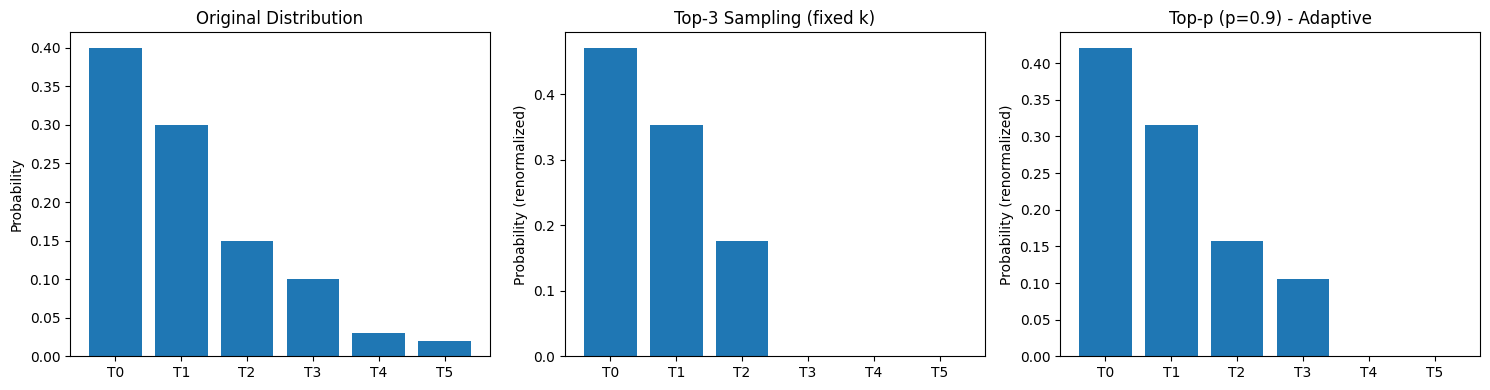


💡 Top-p adapts to distribution shape:
• Sharp distribution: keeps few tokens
• Flat distribution: keeps many tokens
• More flexible than fixed top-k!


In [12]:
def demonstrate_top_p():
    """Show how top-p (nucleus) sampling works"""
    
    # Example probabilities
    probs = torch.tensor([0.4, 0.3, 0.15, 0.1, 0.03, 0.02])
    tokens = [f"T{i}" for i in range(len(probs))]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Original
    axes[0].bar(tokens, probs)
    axes[0].set_title("Original Distribution")
    axes[0].set_ylabel("Probability")
    
    # Top-k (k=3)
    values, indices = torch.topk(probs, 3)
    topk_probs = torch.zeros_like(probs)
    topk_probs[indices] = values
    topk_probs = topk_probs / topk_probs.sum()
    
    axes[1].bar(tokens, topk_probs)
    axes[1].set_title("Top-3 Sampling (fixed k)")
    axes[1].set_ylabel("Probability (renormalized)")
    
    # Top-p (p=0.9)
    sorted_probs, sorted_indices = torch.sort(probs, descending=True)
    cumsum = torch.cumsum(sorted_probs, dim=0)
    mask = cumsum > 0.9
    mask[1:] = mask[:-1].clone()
    mask[0] = False
    
    sorted_probs[mask] = 0
    topp_probs = torch.zeros_like(probs)
    topp_probs[sorted_indices] = sorted_probs
    topp_probs = topp_probs / topp_probs.sum()
    
    axes[2].bar(tokens, topp_probs)
    axes[2].set_title("Top-p (p=0.9) - Adaptive")
    axes[2].set_ylabel("Probability (renormalized)")
    
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Top-p adapts to distribution shape:")
    print("• Sharp distribution: keeps few tokens")
    print("• Flat distribution: keeps many tokens")
    print("• More flexible than fixed top-k!")

demonstrate_top_p()

## 9.6 Complete Hugging Face Pipeline Example

Let's put it all together with a complete example that mirrors our LSTM project:

In [13]:
def complete_hf_pipeline():
    """Complete Hugging Face pipeline for text generation"""
    
    print("="*70)
    print("🏭 COMPLETE HUGGING FACE PIPELINE")
    print("="*70)
    
    # Step 1: Choose a model (GPT-2 small for speed)
    model_name = "gpt2"
    print(f"\n1. 📥 Loading pre-trained model: {model_name}")
    
    # Step 2: Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    
    # Set padding token if not set
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    print(f"   ✓ Vocabulary size: {tokenizer.vocab_size:,}")
    print(f"   ✓ Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Step 3: Prepare prompt
    prompt = "In a magical school called Hogwarts,"
    print(f"\n2. 📝 Prompt: '{prompt}'")
    
    # Step 4: Tokenize
    inputs = tokenizer(prompt, return_tensors='pt', padding=True)
    print(f"   ✓ Tokenized: {inputs['input_ids'].shape}")
    
    # Step 5: Generate with various strategies
    print("\n3. 🎲 Generating with different strategies:")
    
    strategies = {
        "Greedy": {"do_sample": False, "num_beams": 1},
        "Sampling (temp=0.8)": {"do_sample": True, "temperature": 0.8},
        "Top-k (k=50)": {"do_sample": True, "top_k": 50},
        "Top-p (p=0.95)": {"do_sample": True, "top_p": 0.95},
    }
    
    for name, params in strategies.items():
        print(f"\n   🔹 {name}:")
        try:
            outputs = model.generate(
                inputs['input_ids'],
                max_new_tokens=50,
                pad_token_id=tokenizer.eos_token_id,
                **params
            )
            text = tokenizer.decode(outputs[0], skip_special_tokens=True)
            print(f"      {text[:100]}...")
        except Exception as e:
            print(f"      ⚠️ Error: {e}")

complete_hf_pipeline()

🏭 COMPLETE HUGGING FACE PIPELINE

1. 📥 Loading pre-trained model: gpt2
   ✓ Vocabulary size: 50,257
   ✓ Model parameters: 124,439,808

2. 📝 Prompt: 'In a magical school called Hogwarts,'
   ✓ Tokenized: torch.Size([1, 7])

3. 🎲 Generating with different strategies:

   🔹 Greedy:
      In a magical school called Hogwarts, the students were taught to use magic to control their own bodi...

   🔹 Sampling (temp=0.8):
      In a magical school called Hogwarts, a group of young wizards and witches were transformed into the ...

   🔹 Top-k (k=50):
      In a magical school called Hogwarts, its main teacher, Harry Potter , was the main teaching resource...

   🔹 Top-p (p=0.95):
      In a magical school called Hogwarts, a girl who is a little more than a student gets a place in the ...


## 9.7 Mapping Our LSTM Knowledge to Transformers

Everything you learned building the LSTM generator directly applies to transformers!

In [14]:
def map_knowledge_to_transformers():
    """Show how LSTM concepts map to transformers"""
    
    print("="*70)
    print("🔄 MAPPING: What We Learned → Transformers")
    print("="*70)
    
    mapping = [
        ("Character Vocabulary", "Subword Tokenizer (BPE/WordPiece)"),
        ("char2idx dictionary", "tokenizer.encode()"),
        ("idx2char dictionary", "tokenizer.decode()"),
        ("Embedding layer (train from scratch)", "Pre-trained embeddings"),
        ("LSTM layers (sequential)", "Transformer blocks (parallel)"),
        ("Hidden state (memory)", "Attention (direct connections)"),
        ("Linear + Softmax (next token)", "LM Head + Softmax (next token)"),
        ("Temperature sampling", "temperature parameter"),
        ("Top-k sampling", "top_k parameter"),
        ("Manual generate() loop", "model.generate()"),
    ]
    
    print(f"\n{'Our LSTM Concept':<30} {'Transformer Equivalent':<30}")
    print("-" * 60)
    for lstm_concept, transformer in mapping:
        print(f"{lstm_concept:<30} {transformer:<30}")
    
    print("\n" + "="*70)
    print("🎯 KEY INSIGHT:")
    print("The CONCEPTS are the same! Only the ARCHITECTURE changed.")
    print("You now understand 90% of how modern LLMs work!")

map_knowledge_to_transformers()

🔄 MAPPING: What We Learned → Transformers

Our LSTM Concept               Transformer Equivalent        
------------------------------------------------------------
Character Vocabulary           Subword Tokenizer (BPE/WordPiece)
char2idx dictionary            tokenizer.encode()            
idx2char dictionary            tokenizer.decode()            
Embedding layer (train from scratch) Pre-trained embeddings        
LSTM layers (sequential)       Transformer blocks (parallel) 
Hidden state (memory)          Attention (direct connections)
Linear + Softmax (next token)  LM Head + Softmax (next token)
Temperature sampling           temperature parameter         
Top-k sampling                 top_k parameter               
Manual generate() loop         model.generate()              

🎯 KEY INSIGHT:
The CONCEPTS are the same! Only the ARCHITECTURE changed.
You now understand 90% of how modern LLMs work!


## 9.8 The Evolution: From Our LSTM to GPT-3

Let's see the scale difference:

📊 SCALE COMPARISON: Our LSTM vs Modern LLMs

Model           Layers   Hidden   Parameters     
--------------------------------------------------
Our LSTM        3        256      ~0.2M          
GPT-2 Small     12       768      124M           
GPT-2 Medium    24       1024     355M           
GPT-2 Large     36       1280     774M           
GPT-3           96       12288    175B           


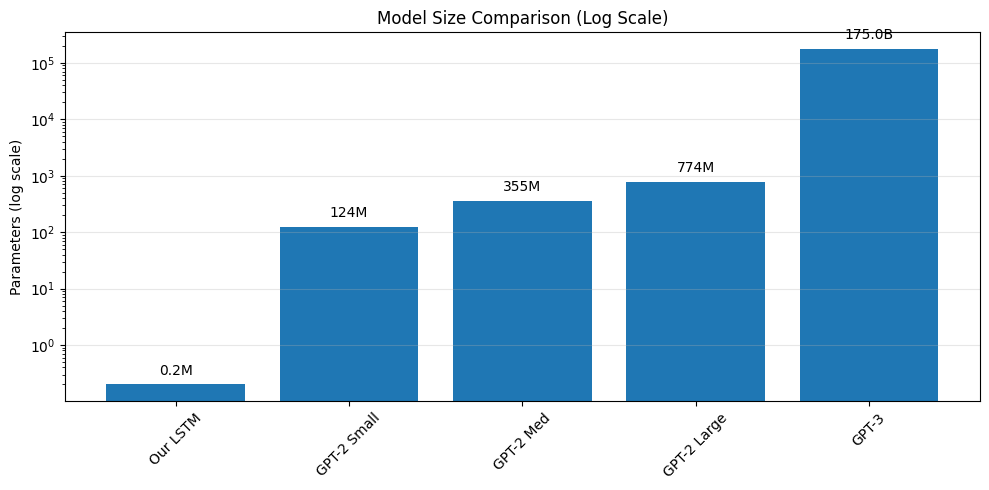


💡 The architecture is SIMILAR - just MUCH bigger!
   Transformers scale far better than LSTMs.


In [15]:
def show_scale_comparison():
    """Compare scale of different models"""
    
    models = [
        ("Our LSTM", 3, 256, 3*256*256 + 256*128, "~0.2M"),
        ("GPT-2 Small", 12, 768, 124_000_000, "124M"),
        ("GPT-2 Medium", 24, 1024, 355_000_000, "355M"),
        ("GPT-2 Large", 36, 1280, 774_000_000, "774M"),
        ("GPT-3", 96, 12288, 175_000_000_000, "175B"),
    ]
    
    print("="*70)
    print("📊 SCALE COMPARISON: Our LSTM vs Modern LLMs")
    print("="*70)
    
    print(f"\n{'Model':<15} {'Layers':<8} {'Hidden':<8} {'Parameters':<15}")
    print("-" * 50)
    for name, layers, hidden, params, param_str in models:
        print(f"{name:<15} {layers:<8} {hidden:<8} {param_str:<15}")
    
    # Visualize the scale (log scale)
    sizes = [0.2, 124, 355, 774, 175000]
    labels = ['Our LSTM', 'GPT-2 Small', 'GPT-2 Med', 'GPT-2 Large', 'GPT-3']
    
    plt.figure(figsize=(10, 5))
    plt.bar(range(len(sizes)), sizes, log=True)
    plt.xticks(range(len(sizes)), labels, rotation=45)
    plt.ylabel("Parameters (log scale)")
    plt.title("Model Size Comparison (Log Scale)")
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, size in enumerate(sizes):
        plt.text(i, size*1.5, f'{size/1000:.1f}B' if size > 1000 else f'{size}M', 
                ha='center')
    
    plt.tight_layout()
    plt.show()
    
    print("\n💡 The architecture is SIMILAR - just MUCH bigger!")
    print("   Transformers scale far better than LSTMs.")

show_scale_comparison()

## 🆕  Bridge to GPT-2 from Scratch Project

```python
"""
FROM OUR LSTM TO GPT-2 FROM SCRATCH:

Our LSTM Generator:               GPT-2 Components:
├── Embedding (char2vec)          ├── Token Embedding (BPE)
├── LSTM layers (sequential)      ├── Transformer Blocks (parallel)
│   └── Hidden state passes info  │   └── Self-Attention (direct connections)
├── Linear + Softmax              ├── LM Head + Softmax
└── generate() with sampling      └── generate() with advanced strategies

KEY UPGRADES IN GPT-2:
1. BPE tokenization (no OOV!)
2. Positional encodings (order info)
3. Multi-head attention (multiple relationship types)
4. LayerNorm (stable training)
5. Huge scale (124M to 1.5B parameters)

You already understand 80% of GPT-2 from this lecture!
"""
```

## 🎯 Key Takeaways: LSTM → Transformers

| Concept | LSTM Implementation | Transformer Implementation |
|---------|---------------------|---------------------------|
| **Tokenization** | Manual char2idx | `AutoTokenizer.from_pretrained()` |
| **Vocabulary** | Built from data | Pre-trained with BPE |
| **Model** | Trained from scratch | Pre-trained on massive data |
| **Generation** | Custom generate() | `model.generate()` with 20+ params |
| **Sampling** | temperature, top_k | temperature, top_k, top_p, beam search |
| **Context** | Hidden state (bounded) | Attention (unbounded) |
| **Parallelization** | Sequential (slow) | Parallel (fast) |

## 🔑 The Magic of Hugging Face

```python
# What took us 300 lines of code and hours of training:
from transformers import pipeline
generator = pipeline('text-generation', model='gpt2')
generator("Your prompt here")

# But NOW you understand what's happening under the hood!
# You're not just calling an API - you KNOW:
# - How tokens are converted to IDs
# - How temperature affects probabilities
# - What top-k and top-p actually do
# - How generation loops work
# - Why transformers are different from LSTMs
```

---

# ✅ PART 10: Mastery Check

## Self-Assessment

Rate your understanding (1-5):

| Concept | Rating |
|---------|--------|
| Many-to-One vs Many-to-Many | □ |
| Two ways to feed data into LSTM | □ |
| Next-token prediction task | □ |
| Teacher Forcing vs Free Running | □ |
| Autoregressive generation | □ |
| Character-level tokenization | □ |
| Training with shifted targets | □ |
| Greedy decoding | □ |
| Temperature sampling | □ |
| Top-k sampling | □ |
| Top-p (nucleus) sampling | □ |
| Beam Search | □ |
| Repetition Penalty | □ |
| Perplexity | □ |
| Hugging Face pipeline | □ |
| Transformer architecture benefits | □ |

## Can You Explain These?

1. **"Why can't we use a Many-to-One model for generation?"**
   - Hint: We need an output at EVERY time step

2. **"What's the difference between teacher forcing and free running?"**
   - Hint: Training vs inference, exposure bias

3. **"What's the difference between character, word, and subword tokenization?"**
   - Hint: Trade-off between vocabulary size and sequence length

4. **"Why is temperature important for generation?"**
   - Hint: Controls creativity vs. predictability

5. **"When would you use top-p instead of top-k?"**
   - Hint: Top-p adapts to the distribution shape

6. **"How does beam search improve over greedy decoding?"**
   - Hint: Keeps multiple hypotheses, avoids local optima

7. **"What is perplexity and why do we use it?"**
   - Hint: exp(loss), interpretable measure of model uncertainty

8. **"How do transformers improve on LSTMs?"**
   - Hint: Attention allows direct connections between any words

9. **"What's the difference between our LSTM generate() and Hugging Face generate()?"**
   - Hint: Parameters like top_p, num_beams, no_repeat_ngram_size

## Experiments to Run

- [ ] Train on different books (Harry Potter vs. Sherlock Holmes)
- [ ] Try different temperatures (0.3, 0.8, 1.2)
- [ ] Try different top-k values (10, 40, 100)
- [ ] Experiment with top-p values (0.8, 0.9, 0.95)
- [ ] Try beam search with different widths (2, 3, 5)
- [ ] Experiment with repetition penalty (1.1, 1.2, 1.5)
- [ ] Compare perplexity across different models
- [ ] Compare Hugging Face models (gpt2, gpt2-medium, gpt2-large)
- [ ] Train on Sudanese Arabic poetry using the same LSTM code

---

# 📚 Further Resources

1. **[The Unreasonable Effectiveness of Recurrent Neural Networks](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)** - Andrej Karpathy
2. **[Understanding LSTM Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)** - Chris Olah
3. **[Attention Is All You Need](https://arxiv.org/abs/1706.03762)** - Original transformer paper
4. **[The Illustrated GPT-2](http://jalammar.github.io/illustrated-gpt2/)** - Jay Alammar
5. **[The Illustrated Transformer](http://jalammar.github.io/illustrated-transformer/)** - Jay Alammar
6. **[Hugging Face Course](https://huggingface.co/learn/nlp-course)** - Free course on transformers
7. **[How to Generate Text](https://huggingface.co/blog/how-to-generate)** - HF blog on generation parameters
8. **[Beam Search Explained](https://huggingface.co/blog/how-to-generate#beam-search)** - Visual guide

---

<div align="center">

## 🌟 Building Sudan's AI Future, One Word at a Time

**You've now built a text generator from scratch AND understand how modern LLMs work!**

From understanding sequences to creating them - you've completed the journey from critic to storyteller.

You've mastered:
- ✅ Teacher Forcing & Free Running
- ✅ Autoregressive Generation
- ✅ Temperature, Top-k, Top-p Sampling
- ✅ Beam Search & Repetition Penalty
- ✅ Perplexity Evaluation
- ✅ Debugging Generation
- ✅ Bridge to GPT-2 from Scratch

**Next: Lecture 7 - Transformers & Attention** 🚀

**SAIR Community - Sudanese Artificial Intelligence Research** 🇸🇩

</div>

# Summrization (What really matter in this lecture):

In [16]:
# some kind of data collection 

# all_text = .........

# Find all unique characters
unique_chars = sorted(list(set(all_text)))
vocab_size = len(unique_chars)

print(f"Unique characters: {vocab_size}")
print(f"Characters: {''.join(unique_chars[:50])}...")

# Create mappings
char2idx = {c:i for i, c in enumerate(unique_chars)}
idx2char = {i:c for i, c in enumerate(unique_chars)}

# Test
test_char = "H"
print(f"\n'{test_char}' → {char2idx[test_char]} → '{idx2char[char2idx[test_char]]}'")

class DataGenerator:
    """Samples random sequences from text for next-character prediction"""
    def __init__(self, text, seq_len=100):
        self.text = text
        self.seq_len = seq_len
        self.total_chars = len(text)

    def get_batch(self, batch_size):
        """Return a batch of (input, target) sequences"""
        inputs = []
        targets = []

        for _ in range(batch_size):
            # Pick random starting point
            start = np.random.randint(0, self.total_chars - self.seq_len - 1)
            end = start + self.seq_len
            
            # Input: sequence, Target: shifted by one
            input_seq = self.text[start:end]
            target_seq = self.text[start+1:end+1]
            
            # Convert to indices
            inputs.append([char2idx[c] for c in input_seq])
            targets.append([char2idx[c] for c in target_seq])

        return torch.tensor(inputs), torch.tensor(targets)

# Test it
data_gen = DataGenerator(all_text, seq_len=20)
x, y = data_gen.get_batch(2)
print(f"Input shape: {x.shape}")
print(f"Target shape: {y.shape}")

# Decode first sample
print(f"\nInput:  {''.join([idx2char[i.item()] for i in x[0]])}")
print(f"Target: {''.join([idx2char[i.item()] for i in y[0]])}")

class LSTMGenerator(nn.Module):
    """LSTM for character-level text generation with advanced features"""
    def __init__(self, vocab_size, embedding_dim=128, hidden_size=256, 
                 num_layers=3, dropout=0.3):
        super().__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # 1. Embedding layer (character index → vector)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # 2. LSTM layers
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # 3. Output layer (hidden state → vocabulary logits)
        self.fc = nn.Linear(hidden_size, vocab_size)

        print(f"✅ LSTM Generator built:")
        print(f"   Vocab size: {vocab_size:,}")
        print(f"   Parameters: {sum(p.numel() for p in self.parameters()):,}")

    def forward(self, x, states=None):
        """
        x: (batch_size, seq_len) - character indices
        states: (h, c) - initial hidden/cell states
        """
        # Embed characters
        x = self.embedding(x)  # (batch, seq_len, embedding_dim)

        # Initialize states if not provided
        if states is None:
            h = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
            c = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
            states = (h, c)

        # LSTM forward
        output, (h_n, c_n) = self.lstm(x, states)

        # Project to vocabulary
        logits = self.fc(output)  # (batch, seq_len, vocab_size)

        return logits, (h_n, c_n)

    def _greedy_sample(self, indices, max_new_tokens):
            device = next(self.parameters()).device
            input_ids = torch.tensor(indices).unsqueeze(0).to(device)

            # Initialize states
            h = torch.zeros(self.num_layers, 1, self.hidden_size).to(device)
            c = torch.zeros(self.num_layers, 1, self.hidden_size).to(device)
            states = (h, c)

            all_indices = indices.copy()

            for _ in range(max_new_tokens):
                with torch.no_grad():
                    logits, states = self(input_ids, states)

                # Last token logits
                logits = logits[0, -1, :]   # shape: [vocab_size]

                # Greedy choice (deterministic)
                next_idx = torch.argmax(logits).item()

                all_indices.append(next_idx)

                # Next input is the predicted token
                input_ids = torch.tensor([[next_idx]]).to(device)

            return ''.join([idx2char[i] for i in all_indices]) 


# maybe explore other concepts like 
# Temp , topk , topp , beam search 

Unique characters: 91
Characters:  !"%&'()*,-./0123456789:;>?ABCDEFGHIJKLMNOPQRSTUVW...

'H' → 34 → 'H'
Input shape: torch.Size([2, 20])
Target shape: torch.Size([2, 20])

Input:   right. “Potions?” s
Target: right. “Potions?” sa
